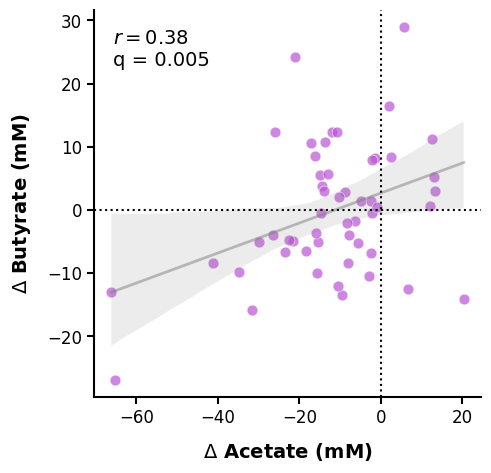

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.multitest as multitest
import warnings
import os

warnings.filterwarnings('ignore')

# =============================================================================
# 1. Settings (Publication Quality)
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
DPI_SETTING = 600

def clean_and_convert(vals):
    s_vals = pd.Series(vals).astype(str).str.strip()
    s_vals = s_vals.replace(['Undetermined', '-', 'nan', 'NaN', '#VALUE!', ''], '0')
    return pd.to_numeric(s_vals, errors='coerce').fillna(0)

# =============================================================================
# 2. Data Loading & Correlation (FDR Correction for SCFA pairs)
# =============================================================================
# Acetate
df_ace = pd.read_csv('Acetate(mM).csv')
donor_cols_ace = [c for c in df_ace.columns if c.startswith('HS-')]
ace_ctrl = clean_and_convert(df_ace[df_ace['KULFFI'].str.strip() == 'Control'][donor_cols_ace].iloc[0])
ace_inulin = clean_and_convert(df_ace[df_ace['KULFFI'].str.strip() == 'Inulin'][donor_cols_ace].iloc[0])
delta_ace = ace_inulin - ace_ctrl

# Butyrate
df_but = pd.read_csv('Butyrate(mM).csv')
donor_cols_but = [c for c in df_but.columns if c.startswith('HS-')]
but_ctrl = clean_and_convert(df_but[df_but['KULFFI'].str.strip() == 'Control'][donor_cols_but].iloc[0])
but_inulin = clean_and_convert(df_but[df_but['KULFFI'].str.strip() == 'Inulin'][donor_cols_but].iloc[0])
delta_but = but_inulin - but_ctrl

# Propionate (For comprehensive SCFA correlation FDR correction)
df_pro = pd.read_csv('Propionate(mM).csv')
donor_cols_pro = [c for c in df_pro.columns if c.startswith('HS-')]
pro_ctrl = clean_and_convert(df_pro[df_pro['KULFFI'].str.strip() == 'Control'][donor_cols_pro].iloc[0])
pro_inulin = clean_and_convert(df_pro[df_pro['KULFFI'].str.strip() == 'Inulin'][donor_cols_pro].iloc[0])
delta_pro = pro_inulin - pro_ctrl

# Calculate P-values for the 3 SCFA combinations (Ace-But, Ace-Pro, Pro-But)
r_ab, p_ab = stats.pearsonr(delta_ace, delta_but)
r_ap, p_ap = stats.pearsonr(delta_ace, delta_pro)
r_pb, p_pb = stats.pearsonr(delta_pro, delta_but)

# FDR Correction across the 3 pairs
p_vals = [p_ab, p_ap, p_pb]
_, q_vals, _, _ = multitest.multipletests(p_vals, alpha=0.05, method='fdr_bh')
q_ab = q_vals[0] # Extract the q-value for Acetate vs Butyrate

df_plot = pd.DataFrame({
    'Delta_Acetate': delta_ace.values,
    'Delta_Butyrate': delta_but.values
})

# =============================================================================
# 3. Figure Generation
# =============================================================================
fig, ax = plt.subplots(figsize=(5, 5))
inulin_color = '#BA55D3'

# Scatter plot and regression line
sns.regplot(x='Delta_Acetate', y='Delta_Butyrate', data=df_plot, ax=ax, color=inulin_color,
            scatter_kws={'s': 60, 'alpha': 0.7, 'edgecolors': 'white', 'linewidths': 0.5},
            line_kws={'linewidth': 2, 'color': 'gray', 'alpha': 0.5, 'linestyle': '-'})

ax.axhline(0, color='black', linestyle=':', linewidth=1.5)
ax.axvline(0, color='black', linestyle=':', linewidth=1.5)

# Labels
ax.set_xlabel(r'$\Delta$ Acetate (mM)', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel(r'$\Delta$ Butyrate (mM)', fontsize=14, fontweight='bold', labelpad=10)

ax.tick_params(axis='both', labelsize=12, width=1.5, length=5)

for spine in ['left', 'bottom']: ax.spines[spine].set_linewidth(1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_box_aspect(1) # Square aspect ratio

# Stats label in the top left corner (Updated to q-value)
q_text = "q < 0.001" if q_ab < 0.001 else f"q = {q_ab:.3f}"
stats_text = f"$r = {r_ab:.2f}$\n{q_text}"

ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
        fontsize=14, fontweight='normal', va='top', ha='left', color='black',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=1.0, edgecolor='none'))

plt.tight_layout()

# =============================================================================
# 4. Output
# =============================================================================
plt.savefig('Figure_4i.pdf', dpi=DPI_SETTING, bbox_inches='tight', transparent=True)